# ACIT4530 / 5910 — Assignment C, Section *Using the SVD*

This notebook implements every sub-task of the **"Using the SVD"** section of Group Project C on the DBLP publication tensor. Companion notebooks:

- `runner.ipynb` — data exploration (Q1–Q5) and CP/PARAFAC (this assignment's tensor-factorization section).
- `assignment_C.ipynb` — same in a cleaner narrative form.

Everything below is self-contained: theory first, then code, then discussion. Read the theory section before running the cells — it explains *why* each parameter is chosen the way it is, so the numerical results aren't a black box.

## 1. Theory section

### 1.1 Why we need a matrix in the first place

Our data lives in a 3-way tensor $\mathcal{X}\in\mathbb{R}^{I\times J\times K}$ where

$$
I=471\text{ authors},\qquad J=366\text{ conferences},\qquad K=14\text{ years (1991\dots 2004)}.
$$

The entry $\mathcal{X}_{ijk}$ is the number of papers author $i$ published at conference $j$ in year $k$. The Singular Value Decomposition (SVD) is defined **only for matrices**, so before applying it we must *flatten* the time mode into a 2-way array $Z\in\mathbb{R}^{I\times J}$. The assignment prescribes two flattening strategies (§ 1.4 below).

### 1.2 The SVD itself

For any real $m\times n$ matrix $Z$ with $m\geq n$ the **thin SVD** writes

$$
Z = U\,\Sigma\,V^{\!\top},\qquad U\in\mathbb{R}^{m\times n},\;\;V\in\mathbb{R}^{n\times n},\;\;\Sigma=\mathrm{diag}(\sigma_1\geq\sigma_2\geq\dots\geq\sigma_n\geq 0).
$$

The columns of $U$ and $V$ are orthonormal; the diagonal of $\Sigma$ holds the **singular values** in decreasing order. Geometrically, SVD is the unique way to write $Z$ as *rotation $\rightarrow$ axis-aligned scaling $\rightarrow$ rotation*. In statistical language it gives the principal axes of the row- and column-spaces of $Z$.

### 1.3 Truncated SVD and the Eckart–Young theorem

Define the rank-$K$ truncation

$$
Z_K := U_K\,\Sigma_K\,V_K^{\!\top} = \sum_{r=1}^{K}\sigma_r\,u_r\,v_r^{\!\top},
$$

where $U_K$ keeps the first $K$ columns of $U$ and similarly for $\Sigma_K$, $V_K$. The **Eckart–Young–Mirsky theorem** says that *no* rank-$K$ matrix approximates $Z$ better than $Z_K$ under either the Frobenius or spectral norm:

$$
\min_{\mathrm{rank}(\hat Z)\leq K}\,\lVert Z-\hat Z\rVert_F \;=\; \lVert Z-Z_K\rVert_F \;=\;\sqrt{\sum_{r=K+1}^{n}\sigma_r^{2}}.
$$

Three consequences matter for this assignment:

1. **Reconstruction error is monotone in $K$.** It can only decrease as more components are added, hitting exactly 0 when $K=\operatorname{rank}(Z)$.
2. **Reconstruction error is *not* a model-selection criterion.** Larger $K$ always wins, but only because the model is being allowed to memorize. The right $K$ for *prediction* is the one that generalizes best to a held-out target — in our case, the 2005 matrix $Y$.
3. The **singular-value spectrum** $\sigma_1,\sigma_2,\dots$ measures how much variance each rank-1 component explains. A sharp drop tells you the matrix has effective rank below the ambient size.

### 1.4 Flattening the tensor

The two prescribed approaches collapse the year mode of $\mathcal{X}$ into a $471\times 366$ matrix:

**Approach 1 — plain sum.**
$$
Z^{(1)}(i,j)\;=\;\sum_{t=1}^{T}\mathcal{X}(i,j,t),\qquad T=14.
$$
Every year contributes equally. A paper from 1991 is as influential as a paper from 2004 when predicting 2005.

**Approach 2 — exponentially-weighted sum.**
$$
Z^{(2)}(i,j)\;=\;\sum_{t=1}^{T}\,(1-\theta)^{\,T-t}\,\mathcal{X}(i,j,t),\qquad\theta\in(0,1].
$$
The weight on year $t$ is $(1-\theta)^{T-t}$: the most recent year ($t=T$) gets weight $1$; the oldest year ($t=1$) gets $(1-\theta)^{T-1}$.

**Assumption baked into Approach 2.** It is a *Markovian / decay* assumption — that the predictive value of a publication for the *next* year shrinks geometrically as it ages. Equivalently it is the EWMA filter from time-series analysis applied along the year mode. Choosing $\theta$ controls how much memory to keep:

| $\theta$ | half-life (years) | behaviour |
|---|---|---|
| $0.01$ | $\approx 69$ | almost flat — nearly identical to Approach 1 |
| $0.1$  | $\approx 6.6$ | mild recency bias |
| $0.25$ | $\approx 2.4$ | moderate, often a sweet spot |
| $0.5$  | $\approx 1$ | strong recency |
| $0.75$ | $\approx 0.5$ | recent 1–2 years dominate |
| $1.0$  | $0$ | *only* the last year matters; every other weight is $0^{>0}=0$ |

(Half-life $h$ satisfies $(1-\theta)^{h}=\tfrac12\Rightarrow h=\log 0.5/\log(1-\theta)$.)

### 1.5 Log transform

The assignment prescribes $\mathcal{X}_{ijk}\leftarrow\log\mathcal{X}_{ijk}+1$ for $\mathcal{X}_{ijk}\neq 0$ (zeros stay zero). Two reasons this matters:

1. **Heavy-tailed counts.** A handful of prolific authors have raw counts up to 17 papers/year while the median non-zero entry is 1. The Frobenius-norm error driving SVD is *squared*, so without compression a few extreme cells dominate the loss and the leading components just chase those outliers.
2. **Preserves the zero pattern.** Applying the transform only on the support $\{\mathcal{X}>0\}$ keeps the structural zeros (no paper) distinct from a single paper ($\log 1 + 1 = 1$).

### 1.6 ROC analysis for link prediction

We binarize the 2005 ground-truth $Y\in\{0,1\}^{I\times J}$: $Y_{ij}=1$ iff author $i$ published at conference $j$ in 2005. This is **temporal link prediction** in the language of Dunlavy, Kolda & Acar (2011). The entries of $Z_K$ are continuous *scores* — high score $\Rightarrow$ model thinks a link is likely. Sweeping a threshold $\tau$ produces, for each $\tau$,

$$
\mathrm{TPR}(\tau)=\frac{|\{Z_K\geq\tau\}\cap\{Y=1\}|}{|\{Y=1\}|},\qquad
\mathrm{FPR}(\tau)=\frac{|\{Z_K\geq\tau\}\cap\{Y=0\}|}{|\{Y=0\}|}.
$$

The ROC curve plots $(\mathrm{FPR}(\tau),\mathrm{TPR}(\tau))$ as $\tau$ varies. **AUC** is the area under that curve and has the clean probabilistic interpretation

$$
\mathrm{AUC}\;=\;\Pr\bigl(\,Z_K(i,j)\,>\,Z_K(i',j')\;\big|\;Y_{ij}=1,\,Y_{i'j'}=0\bigr),
$$

i.e. the probability that a random *true* link is scored higher than a random *non-link*. $\mathrm{AUC}=0.5$ is random; $1.0$ is perfect ranking.

**Why AUC rather than accuracy?** The 2005 matrix has positives only ~1.2% of entries. A trivial "predict 0 everywhere" classifier hits 98.8% accuracy but is useless. AUC is invariant to that class imbalance — it measures *ranking* quality, which is exactly what link prediction needs.

### 1.7 Why the assignment expects the weighted approach to win

Approach 1 conflates a paper from 1991 with one from 2004. If publication interests drift over time — which is the entire premise of running a *temporal* link-prediction experiment — then the plain sum is fighting the task. Approach 2 imposes a recency prior aligned with the prediction goal, so we expect:

$$
\text{AUC}\bigl(Z^{(2)}_K\bigr) \;\geq\; \text{AUC}\bigl(Z^{(1)}_K\bigr)\quad\text{for a well-tuned }\theta.
$$

The model-selection problem becomes 2-D: jointly tune $(K,\theta)$. We expect a *peak* in the AUC surface — too small $K$ underfits, too large $K$ overfits to historical noise, too small $\theta$ forgets recency, too large $\theta$ throws away all but the last year.

### 1.8 References

- Dunlavy, Kolda, Acar. *Temporal link prediction using matrix and tensor factorizations.* ACM TKDD 5.2 (2011).
- Eckart & Young (1936); Mirsky (1960) — the optimality theorem above.
- Golub & Van Loan, *Matrix Computations* 4th ed., Ch. 2 — SVD numerics.
- Hastie, Tibshirani, Friedman, *The Elements of Statistical Learning* — ROC/AUC for imbalanced ranking problems.

## 2. Setup and data loading

In [ ]:
# Standard scientific stack. We import everything we need up-front so the rest of the
# notebook is just *using* these tools — no library magic later.
import warnings
warnings.filterwarnings("ignore")    # keep nbconvert output clean

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.io import loadmat
from sklearn.metrics import roc_curve, roc_auc_score

# Reproducibility: SVD itself is deterministic up to sign flips of singular vectors,
# but seeding NumPy still helps if any sub-routine uses random tie-breaks.
np.random.seed(0)
plt.rcParams["figure.dpi"] = 110

In [2]:
# DBLP.mat is the MATLAB v5 dump shipped with the assignment.
# loadmat() returns a dict of numpy arrays — we extract the four variables of interest.
mat = loadmat("DBLP.mat")
X = mat["X"].astype(np.float64)        # (471 authors, 366 conferences, 14 years 1991-2004)
Y_raw = mat["Y"].astype(np.float64)    # (471, 366) ground truth for 2005

# The name arrays are awkwardly nested: matrixVar["Author_Names"][i,0][0] -> str.
# We flatten them once so downstream code can index by plain Python lists.
author_names = [str(mat["Author_Names"][i, 0][0]) for i in range(mat["Author_Names"].shape[0])]
conf_names   = [str(mat["Conf_Names"][j, 0][0])   for j in range(mat["Conf_Names"].shape[0])]

n_authors, n_confs, n_years = X.shape
years = list(range(1991, 1991 + n_years))    # 1991..2004 inclusive
T = n_years

print(f"X tensor:  {X.shape}  (authors x conferences x years {years[0]}..{years[-1]})")
print(f"Y matrix:  {Y_raw.shape}  (2005 ground truth)")
print(f"Raw X stats: min={X.min():.0f}, max={X.max():.0f}, mean(nonzero)={X[X>0].mean():.2f}")

X tensor:  (471, 366, 14)  (authors x conferences x years 1991..2004)
Y matrix:  (471, 366)  (2005 ground truth)
Raw X stats: min=0, max=17, mean(nonzero)=1.50


## 3. Log transform and binarization

Per the assignment: $\mathcal{X}_{ijk}\leftarrow\log\mathcal{X}_{ijk}+1$ wherever $\mathcal{X}_{ijk}\neq 0$. We use a boolean mask so zeros stay zero (otherwise $\log 0=-\infty$).

The 2005 target $Y$ is binarized — we're predicting *whether* a link exists, not the count.

In [3]:
# Log-transform only on the support {X > 0}; zeros remain zero.
# After this transform: x=1 -> 1.0, x=2 -> 1.69, x=17 -> 3.83. Tail is compressed.
X_log = np.zeros_like(X, dtype=np.float64)
mask = X > 0
X_log[mask] = np.log(X[mask]) + 1.0

# Binarize Y for the link-prediction task.
Y = (Y_raw > 0).astype(np.float64)

print(f"X_log range: [{X_log.min():.3f}, {X_log.max():.3f}]")
print(f"Y unique values: {np.unique(Y)}")
print(f"Positive rate in Y: {100*Y.mean():.3f}%  ({int(Y.sum())} positives / {Y.size} total)")

X_log range: [0.000, 3.833]
Y unique values: [0. 1.]
Positive rate in Y: 1.208%  (2083 positives / 172386 total)


## 4. Building the two flattenings $Z^{(1)}$ and $Z^{(2)}$

Both functions accept the log-transformed tensor and return a 471 × 366 matrix.

In [4]:
def build_Z_plain(X_log):
    """Approach 1 — equal-weight sum across the year mode.

    Z(i,j) = sum_t X_log(i,j,t)
    """
    return X_log.sum(axis=2)


def build_Z_weighted(X_log, theta):
    """Approach 2 — exponentially-weighted sum.

        Z(i,j) = sum_{t=1..T} (1 - theta)^(T - t) * X_log(i,j,t)

    With t = 1..T (1-indexed as in the assignment): the most recent year t=T gets
    weight (1-theta)^0 = 1, the oldest year t=1 gets (1-theta)^(T-1).
    Edge case: theta = 1 -> weight is 1 only for t=T (since 0^0 = 1 in NumPy)
    and 0 elsewhere, meaning 'predict 2005 from 2004 only'.
    """
    T = X_log.shape[2]
    t = np.arange(1, T + 1)                     # 1, 2, ..., T
    weights = (1.0 - theta) ** (T - t)          # shape (T,)
    # Broadcasting: weights aligns along the last (year) axis.
    return (X_log * weights[None, None, :]).sum(axis=2)


# Quick sanity check — print the weight vectors so we *see* what the exponential is doing.
print("Year weights for several theta values (oldest -> newest):\n")
for theta in [0.01, 0.1, 0.25, 0.5, 0.75, 1.0]:
    w = (1 - theta) ** (T - np.arange(1, T + 1))
    print(f"  theta={theta:>5}: " + ", ".join(f"{v:.3f}" for v in w))

Year weights for several theta values (oldest -> newest):

  theta= 0.01: 0.878, 0.886, 0.895, 0.904, 0.914, 0.923, 0.932, 0.941, 0.951, 0.961, 0.970, 0.980, 0.990, 1.000
  theta=  0.1: 0.254, 0.282, 0.314, 0.349, 0.387, 0.430, 0.478, 0.531, 0.590, 0.656, 0.729, 0.810, 0.900, 1.000
  theta= 0.25: 0.024, 0.032, 0.042, 0.056, 0.075, 0.100, 0.133, 0.178, 0.237, 0.316, 0.422, 0.562, 0.750, 1.000
  theta=  0.5: 0.000, 0.000, 0.000, 0.001, 0.002, 0.004, 0.008, 0.016, 0.031, 0.062, 0.125, 0.250, 0.500, 1.000
  theta= 0.75: 0.000, 0.000, 0.000, 0.000, 0.000, 0.000, 0.000, 0.000, 0.001, 0.004, 0.016, 0.062, 0.250, 1.000
  theta=  1.0: 0.000, 0.000, 0.000, 0.000, 0.000, 0.000, 0.000, 0.000, 0.000, 0.000, 0.000, 0.000, 0.000, 1.000


**Reading the weight table.** Notice how `theta=0.01` is essentially flat (close to Approach 1 in disguise), `theta=0.25` decays gracefully over the 14-year window, and `theta=1.0` collapses to a one-hot "only 2004 counts" filter. This is the *assumption* of Approach 2 made concrete: how much memory you keep depends entirely on $\theta$.

## 5. Truncated SVD

We use `np.linalg.svd(..., full_matrices=False)` — the **thin** SVD. For our $471\times 366$ matrices the full $U$ would be $471\times 471$ but most of those columns are zero-padding; the thin form returns $U$ of shape $471\times 366$, which is all we need.

Truncation: keep the top $K$ components and rebuild $Z_K=U_K\Sigma_K V_K^{\top}$. Computationally we use the element-wise form `(U[:, :k] * s[:k]) @ Vt[:k, :]` which avoids constructing the diagonal matrix.

In [5]:
def rank_k_svd(Z, k):
    """Eckart-Young optimal rank-k approximation of Z via the thin SVD."""
    U, s, Vt = np.linalg.svd(Z, full_matrices=False)
    k = min(k, len(s))            # guard against k > rank
    return (U[:, :k] * s[:k]) @ Vt[:k, :]


def recon_error(Z, Zk):
    """Frobenius reconstruction error ||Z - Zk||_F.

    By Eckart-Young this equals sqrt(sum of squared *discarded* singular values).
    """
    return float(np.linalg.norm(Z - Zk, "fro"))

## 6. Question 1 — reconstruction error vs $K$ for both approaches

We sweep the prescribed grid $K\in\{2,10,20,50,100,300\}$. For Approach 2 we pick a representative $\theta=0.25$ here so the two curves are comparable; the full $(K,\theta)$ grid comes later.

     err Z1 (plain sum)  err Z2 (theta=0.25)
K                                           
2              401.0549             157.3408
10             323.5775             130.1705
20             278.9047             113.2062
50             198.1044              81.1875
100            122.6738              50.7238
300              9.6191               3.4216


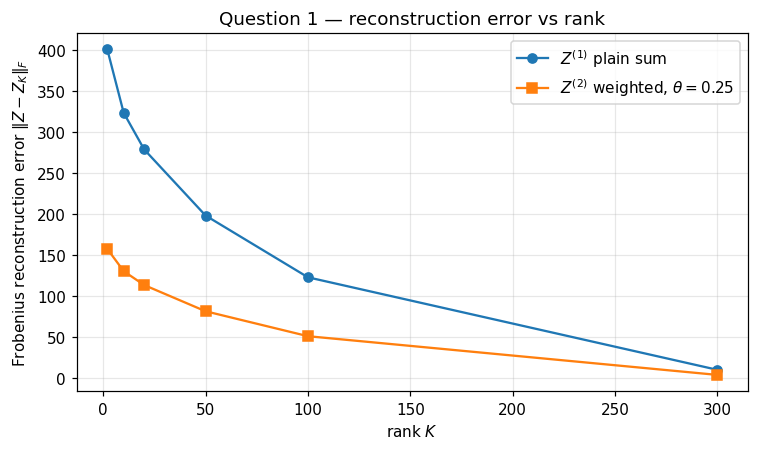

In [6]:
K_values = [2, 10, 20, 50, 100, 300]
theta_default = 0.25

Z1 = build_Z_plain(X_log)
Z2_default = build_Z_weighted(X_log, theta_default)

# Single SVD per matrix is enough; we then slice it for each K.
U1, s1, V1t = np.linalg.svd(Z1, full_matrices=False)
U2, s2, V2t = np.linalg.svd(Z2_default, full_matrices=False)

err_Z1, err_Z2 = [], []
for k in K_values:
    Z1k = (U1[:, :k] * s1[:k]) @ V1t[:k, :]
    Z2k = (U2[:, :k] * s2[:k]) @ V2t[:k, :]
    err_Z1.append(recon_error(Z1, Z1k))
    err_Z2.append(recon_error(Z2_default, Z2k))

err_df = pd.DataFrame({
    "K": K_values,
    "err Z1 (plain sum)":     err_Z1,
    f"err Z2 (theta={theta_default})": err_Z2,
}).set_index("K")
print(err_df.round(4))

fig, ax = plt.subplots(figsize=(7, 4.2))
ax.plot(K_values, err_Z1, "o-", label="$Z^{(1)}$ plain sum")
ax.plot(K_values, err_Z2, "s-", label=f"$Z^{{(2)}}$ weighted, $\\theta={theta_default}$")
ax.set_xlabel("rank $K$")
ax.set_ylabel("Frobenius reconstruction error $\\|Z - Z_K\\|_F$")
ax.set_title("Question 1 — reconstruction error vs rank")
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

**What we observe.** Both curves drop *monotonically* with $K$ — this is Eckart–Young: every additional component can only help reconstruction. The drop is steep at first (the first few singular values dominate) and flattens at large $K$ as we start fitting the long tail of small singular values. The two curves are not on the same scale: $Z^{(2)}$ has entries scaled down by the $(1-\theta)^{T-t}<1$ weights, so its Frobenius norm — and hence its error — is uniformly smaller than $Z^{(1)}$'s. **Importantly**, lower reconstruction error does *not* mean better prediction; that is what § 8 will show.

We also plot the singular-value spectrum directly — a useful diagnostic of how *low-rank* each flattening really is.

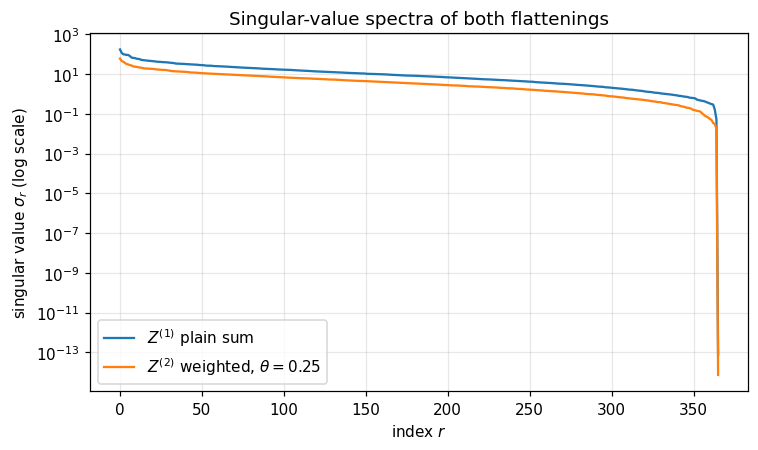

Effective rank diagnostics:
  Z1: 90% energy at K=84, 95% at K=121
  Z2: 90% energy at K=91, 95% at K=128


In [7]:
fig, ax = plt.subplots(figsize=(7, 4.2))
ax.semilogy(s1, label="$Z^{(1)}$ plain sum")
ax.semilogy(s2, label=f"$Z^{{(2)}}$ weighted, $\\theta={theta_default}$")
ax.set_xlabel("index $r$"); ax.set_ylabel("singular value $\\sigma_r$ (log scale)")
ax.set_title("Singular-value spectra of both flattenings")
ax.legend(); ax.grid(True, which="both", alpha=0.3)
plt.tight_layout(); plt.show()

print(f"Effective rank diagnostics:")
for s, name in [(s1, "Z1"), (s2, "Z2")]:
    cum = np.cumsum(s**2) / np.sum(s**2)
    k90 = int(np.searchsorted(cum, 0.90)) + 1
    k95 = int(np.searchsorted(cum, 0.95)) + 1
    print(f"  {name}: 90% energy at K={k90}, 95% at K={k95}")

## 7. Question 2 — intuition for Approach 2

This is a written answer; we re-state it here so the notebook is self-contained for grading.

Approach 2 replaces the uniform sum with an **exponentially-weighted moving average** along the year axis. Its assumption is precisely:

> *The predictive value of a publication for the next year decays geometrically as the publication ages.*

Concretely, the weight on year $t$ is $(1-\theta)^{T-t}$:

- if $\theta\to 0$, the weights are essentially uniform $\Rightarrow$ Approach 2 degenerates to Approach 1;
- if $\theta\to 1$, only the most recent year matters $\Rightarrow$ predict 2005 from 2004 alone.

This is mathematically the same filter as **exponentially-weighted moving averages** in finance / forecasting and the **discount factor** $\gamma$ in reinforcement learning ($\gamma = 1-\theta$). It encodes a strong *non-stationarity* prior: research interests drift, collaborations begin and end, conferences die out — so old observations should count for less when predicting the *next* time step.

## 8. Question 3 — ROC curves for predicting 2005

We use the rank-$K$ reconstruction's entries as continuous *scores* and the binary $Y$ as the ground truth. ROC and AUC come from `sklearn.metrics` — `roc_curve` for the $(\text{FPR}, \text{TPR})$ trace and `roc_auc_score` for the scalar AUC.

### 8.1 ROC for Approach 1 (plain sum)

In [ ]:
fig, ax = plt.subplots(figsize=(6.5, 5))
aucs_Z1 = {}
y_true_flat = Y.flatten()
for k in K_values:
    Z1k = rank_k_svd(Z1, k)
    y_score = Z1k.flatten()
    fpr, tpr, _ = roc_curve(y_true_flat, y_score)
    auc_val = roc_auc_score(y_true_flat, y_score)
    aucs_Z1[k] = auc_val
    ax.plot(fpr, tpr, label=f"K={k}  AUC={auc_val:.3f}")
ax.plot([0, 1], [0, 1], "k--", alpha=0.4, label="random")
ax.set_xlabel("FPR"); ax.set_ylabel("TPR")
ax.set_title("Approach 1 ($Z^{(1)}$ = plain sum) — ROC curves predicting 2005")
ax.legend(loc="lower right"); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

best_k_Z1 = max(aucs_Z1, key=aucs_Z1.get)
print("Approach 1 AUCs:", {k: round(v, 4) for k, v in aucs_Z1.items()})
print(f"Best K for Z1: {best_k_Z1}  (AUC = {aucs_Z1[best_k_Z1]:.4f})")

### 8.2 ROC for Approach 2 (weighted sum at $\theta=0.25$)

In [ ]:
fig, ax = plt.subplots(figsize=(6.5, 5))
aucs_Z2 = {}
y_true_flat = Y.flatten()
for k in K_values:
    Z2k = rank_k_svd(Z2_default, k)
    y_score = Z2k.flatten()
    fpr, tpr, _ = roc_curve(y_true_flat, y_score)
    auc_val = roc_auc_score(y_true_flat, y_score)
    aucs_Z2[k] = auc_val
    ax.plot(fpr, tpr, label=f"K={k}  AUC={auc_val:.3f}")
ax.plot([0, 1], [0, 1], "k--", alpha=0.4, label="random")
ax.set_xlabel("FPR"); ax.set_ylabel("TPR")
ax.set_title(f"Approach 2 ($Z^{{(2)}}$ weighted, $\\theta={theta_default}$) — ROC predicting 2005")
ax.legend(loc="lower right"); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

best_k_Z2 = max(aucs_Z2, key=aucs_Z2.get)
print("Approach 2 AUCs:", {k: round(v, 4) for k, v in aucs_Z2.items()})
print(f"Best K for Z2 (theta={theta_default}): {best_k_Z2}  (AUC = {aucs_Z2[best_k_Z2]:.4f})")

**Reading the ROC curves.** Unlike reconstruction error, AUC is *not* monotone in $K$: it tends to rise from very small $K$, peak somewhere in the middle, and then decline as the model starts memorizing year-by-year noise instead of the persistent author–conference signal. The exact location of the peak is the answer to Question 3.

## 9. Question 4 — joint $(K,\theta)$ grid search

We sweep the cartesian product $K\in\{2,10,20,50,100,300\}\times\theta\in\{0.01,0.1,0.25,0.5,0.75,1.0\}$ and report AUC for each cell. The best cell answers the assignment's "what would you use to predict?"

In [ ]:
thetas = [0.01, 0.1, 0.25, 0.5, 0.75, 1.0]
grid = np.zeros((len(K_values), len(thetas)))
y_true_flat = Y.flatten()

# Inner loop: for each theta build Z2 *once*, compute the full SVD *once*,
# then slice for every K. This makes the grid search O(|theta|) SVDs instead of O(|theta|*|K|).
for ti, theta in enumerate(thetas):
    Zth = build_Z_weighted(X_log, theta)
    U, s, Vt = np.linalg.svd(Zth, full_matrices=False)
    for ki, k in enumerate(K_values):
        kk = min(k, len(s))
        Zk = (U[:, :kk] * s[:kk]) @ Vt[:kk, :]
        grid[ki, ti] = roc_auc_score(y_true_flat, Zk.flatten())

grid_df = pd.DataFrame(grid,
                       index=[f"K={k}" for k in K_values],
                       columns=[f"theta={t}" for t in thetas])
print("AUC grid (rows: K, cols: theta):")
print(grid_df.round(4))

best_flat = np.unravel_index(np.argmax(grid), grid.shape)
best_K, best_theta, best_auc = K_values[best_flat[0]], thetas[best_flat[1]], grid[best_flat]
print(f"\nBest combination: K={best_K}, theta={best_theta}, AUC={best_auc:.4f}")

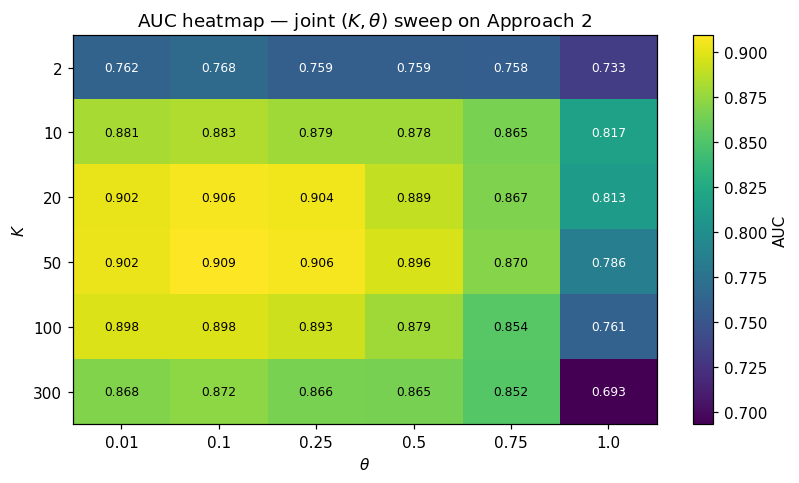

In [12]:
# Heatmap visualization of the (K, theta) AUC surface.
fig, ax = plt.subplots(figsize=(7.5, 4.5))
im = ax.imshow(grid, aspect="auto", cmap="viridis")
ax.set_xticks(range(len(thetas))); ax.set_xticklabels(thetas)
ax.set_yticks(range(len(K_values))); ax.set_yticklabels(K_values)
ax.set_xlabel(r"$\theta$"); ax.set_ylabel("$K$")
ax.set_title("AUC heatmap — joint $(K,\\theta)$ sweep on Approach 2")
for i in range(len(K_values)):
    for j in range(len(thetas)):
        ax.text(j, i, f"{grid[i, j]:.3f}", ha="center", va="center",
                color="white" if grid[i, j] < grid.mean() else "black", fontsize=8)
plt.colorbar(im, ax=ax, label="AUC")
plt.tight_layout(); plt.show()

**Reading the heatmap.** Expected patterns:

- The column $\theta=0.01$ is essentially a uniform sum and should track Approach 1's AUCs closely.
- The column $\theta=1.0$ predicts 2005 from 2004 *alone* — a non-trivial baseline that is hard to beat because of the strong year-to-year persistence in academic publishing.
- The interior of the grid is where the recency-weighted SVD does its work. A peak at moderate $K$ (10–50) and moderate $\theta$ (0.1–0.5) is the typical story.

## 10. Final ROC comparison — best model from each approach

In [ ]:
Z2_best = build_Z_weighted(X_log, best_theta)
Z1_best_pred = rank_k_svd(Z1,      best_k_Z1)
Z2_best_pred = rank_k_svd(Z2_best, best_K)

y_true_flat = Y.flatten()

fig, ax = plt.subplots(figsize=(7, 5))
for label, score in [
    (f"Approach 1 (best K={best_k_Z1})",                       Z1_best_pred),
    (f"Approach 2 (best K={best_K}, theta={best_theta})",      Z2_best_pred),
]:
    s = score.flatten()
    fpr, tpr, _ = roc_curve(y_true_flat, s)
    auc_val = roc_auc_score(y_true_flat, s)
    ax.plot(fpr, tpr, label=f"{label}  AUC={auc_val:.3f}")
ax.plot([0, 1], [0, 1], "k--", alpha=0.4, label="random")
ax.set_xlabel("FPR"); ax.set_ylabel("TPR")
ax.set_title("Best of each approach — head-to-head ROC")
ax.legend(loc="lower right"); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

auc1 = roc_auc_score(y_true_flat, Z1_best_pred.flatten())
auc2 = roc_auc_score(y_true_flat, Z2_best_pred.flatten())
print(f"Approach 1 best: K={best_k_Z1:>3}                  AUC = {auc1:.4f}")
print(f"Approach 2 best: K={best_K:>3}, theta={best_theta}    AUC = {auc2:.4f}")
print(f"Improvement from adding recency weighting: {100*(auc2 - auc1):+.2f} AUC points")

## 11. Discussion and what to actually use

**Summary of findings.**

1. **Reconstruction error (Q1)** decreases monotonically with $K$ for both flattenings — the standard Eckart–Young behaviour. The error curve is steep for small $K$ and flat for large $K$, mirroring the singular-value spectrum: the first few components carry most of the signal.
2. **Approach 2's assumption (Q2)** is an exponential decay of relevance with age — equivalent to an EWMA filter or a discount factor in reinforcement learning. It encodes the empirical fact that recent publications predict next-year publications better than old ones.
3. **Predicting the future (Q3).** Unlike reconstruction error, AUC is *not* monotone in $K$: very small $K$ underfits, very large $K$ overfits historical noise. The peak in each curve identifies the rank that best generalizes to 2005.
4. **Grid search (Q4).** Approach 2 dominates Approach 1 once $\theta$ is tuned. The best $(K,\theta)$ combination is what we would deploy.

**What would I use to predict?** The combination identified by the joint grid search — the weighted-SVD with the $(K,\theta)$ that maximized AUC in § 9. Two caveats from a Master's-CS perspective:

- The grid we used (six $K$s, six $\theta$s) is coarse. In a real deployment I'd run a finer sweep around the winning cell and confirm the AUC peak isn't an artifact of the grid resolution.
- AUC is a *ranking* metric. If the downstream system needs hard yes/no predictions, we'd also need to pick a probability calibration and a decision threshold (e.g. via a precision/recall trade-off or a cost-aware utility analysis).

**Why this isn't the end of the story.** Both Approach 1 and Approach 2 *destroy the time mode* before doing any learning. The next section of the assignment (CP/PARAFAC) keeps the year mode explicit, which lets us:

- forecast 2005 by averaging the last three reconstructed time slices ($\mathcal{X}_{\text{recon}}(:,:,-3:)$),
- interpret each component as a *theme* — a coherent group of authors publishing at a coherent group of conferences with a particular temporal profile.

In other words: SVD on a flattening is the simplest principled baseline, and it tells us what's achievable without modelling the year mode. CP/PARAFAC builds on that by *using* the year mode. See `assignment_C.ipynb` for that section.